In [139]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_percentage_error

from prophet import Prophet
from prophet.diagnostics import cross_validation
from prophet.diagnostics import performance_metrics
import itertools

import warnings
warnings.filterwarnings('ignore')

In [140]:
df_train = pd.read_csv("./dataset/train.csv")
df_fullfilment = pd.read_csv("./dataset/fulfilment_center_info.csv")
df_meal = pd.read_csv("./dataset/meal_info.csv")
df_test = pd.read_csv("./dataset/test.csv")

In [141]:
print(f"Train data: {df_train.shape}")
print(f"Test data: {df_test.shape}")
print(f"Fullfilment_center_info data: {df_fullfilment.shape}")
print(f"Meal_info data: {df_meal.shape}")

Train data: (456548, 9)
Test data: (32573, 8)
Fullfilment_center_info data: (77, 5)
Meal_info data: (51, 3)


In [142]:
df_train.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40


In [143]:
df_test.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured
0,1028232,146,55,1885,158.11,159.11,0,0
1,1127204,146,55,1993,160.11,159.11,0,0
2,1212707,146,55,2539,157.14,159.14,0,0
3,1082698,146,55,2631,162.02,162.02,0,0
4,1400926,146,55,1248,163.93,163.93,0,0


In [144]:
df_fullfilment.head()

,center_id,city_code,region_code,center_type,op_area
0,11,679,56,TYPE_A,3.7
1,13,590,56,TYPE_B,6.7
2,124,590,56,TYPE_C,4.0
3,66,648,34,TYPE_A,4.1
4,94,632,34,TYPE_C,3.6


In [145]:
df_meal.head()

,meal_id,category,cuisine
0,1885,Beverages,Thai
1,1993,Beverages,Thai
2,2539,Beverages,Thai
3,1248,Beverages,Indian
4,2631,Beverages,Indian


In [146]:
df_train.describe()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
count,4.565480e+05,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.00000,456548.000000
mean,1.250096e+06,74.768771,82.105796,2024.337458,332.238933,354.156627,0.081152,0.10920,261.872760
std,1.443548e+05,41.524956,45.975046,547.420920,152.939723,160.715914,0.273069,0.31189,395.922798
min,1.000000e+06,1.000000,10.000000,1062.000000,2.970000,55.350000,0.000000,0.00000,13.000000
25%,1.124999e+06,39.000000,43.000000,1558.000000,228.950000,243.500000,0.000000,0.00000,54.000000
50%,1.250184e+06,76.000000,76.000000,1993.000000,296.820000,310.460000,0.000000,0.00000,136.000000
75%,1.375140e+06,111.000000,110.000000,2539.000000,445.230000,458.870000,0.000000,0.00000,324.000000
max,1.499999e+06,145.000000,186.000000,2956.000000,866.270000,866.270000,1.000000,1.00000,24299.000000


In [147]:
df_train.isnull().sum()

id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
dtype: int64

In [148]:
df_meal["category"].unique(), df_meal["cuisine"].unique()

(<StringArray>
 [   'Beverages',       'Extras',         'Soup', 'Other Snacks',
         'Salad',    'Rice Bowl',     'Starters',     'Sandwich',
         'Pasta',       'Desert',      'Biryani',        'Pizza',
          'Fish',      'Seafood']
 Length: 14, dtype: str,
 <StringArray>
 ['Thai', 'Indian', 'Italian', 'Continental']
 Length: 4, dtype: str)

In [149]:
print(df_train.shape)
df = df_train.merge(df_fullfilment, on="center_id", how='left')
df = df.merge(df_meal, on="meal_id", how="left")
print(df.shape)

(456548, 9)
(456548, 15)


In [150]:
df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian


In [151]:
df_temp = df.groupby(by="category").agg({"cuisine": "nunique"}).reset_index()
df_temp

,category,cuisine
0,Beverages,4
1,Biryani,1
2,Desert,1
3,Extras,1
4,Fish,1
5,Other Snacks,1
6,Pasta,1
7,Pizza,1
8,Rice Bowl,1
9,Salad,1


### Observation
* Other than 'Beverages', all other categories are unique to their cuisine

In [152]:
df_temp = df.groupby(by="center_id").agg({"cuisine": "nunique"}).reset_index().sort_values('cuisine')
df_temp['cuisine'].min(), df_temp['cuisine'].max(), df_temp['cuisine'].mean(), df_temp['cuisine'].median()

(np.int64(4), np.int64(4), np.float64(4.0), np.float64(4.0))

In [153]:
df_temp = df.groupby(by="center_id").agg({"category": "nunique"}).reset_index().sort_values('category')
df_temp['category'].min(), df_temp['category'].max(), df_temp['category'].mean(), df_temp['category'].median()

(np.int64(11), np.int64(14), np.float64(12.766233766233766), np.float64(12.0))

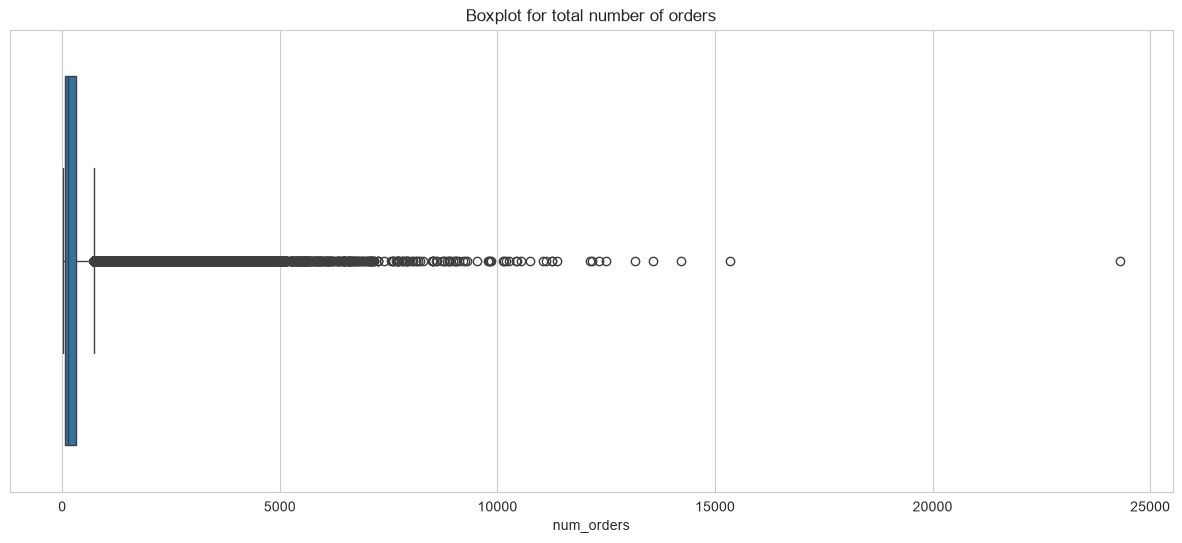

In [154]:
plt.figure(figsize=(15,6))
sns.boxplot(data = df, x="num_orders")
plt.title("Boxplot for total number of orders")
plt.show()

In [155]:
df['center_meal'] = df.apply(lambda x: f"{x['center_id']}_{x['meal_id']}", axis=1)
df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,center_meal
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,55_1885
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,55_1993
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,55_2539
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,55_2139
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,55_2631


In [156]:
df['center_id'].nunique(), df['meal_id'].nunique(), df['center_meal'].nunique(), df['city_code'].nunique(), df['region_code'].nunique(), len(df), df['week'].max()

(77, 51, 3597, 51, 8, 456548, np.int64(145))

In [157]:
weeks = range(1, df['week'].max()+1)
df_forecastibility = (
    df.groupby(['center_id', 'meal_id', 'center_meal'])
    .apply(lambda x: pd.Series({
        'total_obs': len(weeks),
        'non_zero_obs': (x['num_orders'] >0).sum(),
        'ADI': (len(weeks)/(x['num_orders']>0).sum() if (x['num_orders']>0).any() else None),
        'CV2': (x.loc[x['num_orders'] > 0, 'num_orders'].std()/ x.loc[x['num_orders'] > 0, 'num_orders'].mean()) **2,
        'cor_baseprice': x['num_orders'].corr(x['base_price']),
        'cor_checkoutprice': x['num_orders'].corr(x['checkout_price']),
        'cor_email': x['num_orders'].corr(x['emailer_for_promotion']),
        'cor_homepage': x['num_orders'].corr(x['homepage_featured'])
    })).reset_index()
)
df_forecastibility['SBC'] = np.select(
    [
        (df_forecastibility['ADI'] < 1.32) & (df_forecastibility['CV2'] < 0.49),
        (df_forecastibility['ADI'] >= 1.32) & (df_forecastibility['CV2'] < 0.49),
        (df_forecastibility['ADI'] < 1.32) & (df_forecastibility['CV2'] >= 0.49),
        (df_forecastibility['ADI'] >= 1.32) & (df_forecastibility['CV2'] >= 0.49)
    ],
    ['Smooth', 'Intermittent', 'Erratic', 'Lumpy'],
    default='NA'
)
df_forecastibility.head()

,center_id,meal_id,center_meal,total_obs,non_zero_obs,ADI,CV2,cor_baseprice,cor_checkoutprice,cor_email,cor_homepage,SBC
0,10,1062,10_1062,145.0,145.0,1.000000,0.075145,0.105204,-0.400973,0.290483,0.215389,Smooth
1,10,1109,10_1109,145.0,145.0,1.000000,0.171756,0.028419,-0.424526,0.797420,0.726589,Smooth
2,10,1198,10_1198,145.0,145.0,1.000000,0.167105,0.291807,0.256622,NaN,0.187330,Smooth
3,10,1207,10_1207,145.0,144.0,1.006944,0.670863,-0.005901,-0.594153,0.388854,0.537746,Erratic
4,10,1216,10_1216,145.0,143.0,1.013986,0.161993,0.031092,-0.312121,0.100416,0.066141,Smooth


In [158]:
df_forecastibility.groupby(by='SBC').agg({'non_zero_obs': ['count', 'min', 'max', 'mean', 'median'] }).round(1)

non_zero_obs                            
                    count    min    max   mean median
SBC                                                  
Erratic              1221  110.0  145.0  137.6  143.0
Intermittent          412    3.0  109.0   70.0   77.0
Lumpy                 199    3.0  109.0   77.7   83.0
NA                      3    1.0    1.0    1.0    1.0
Smooth               1762  110.0  145.0  138.6  144.0

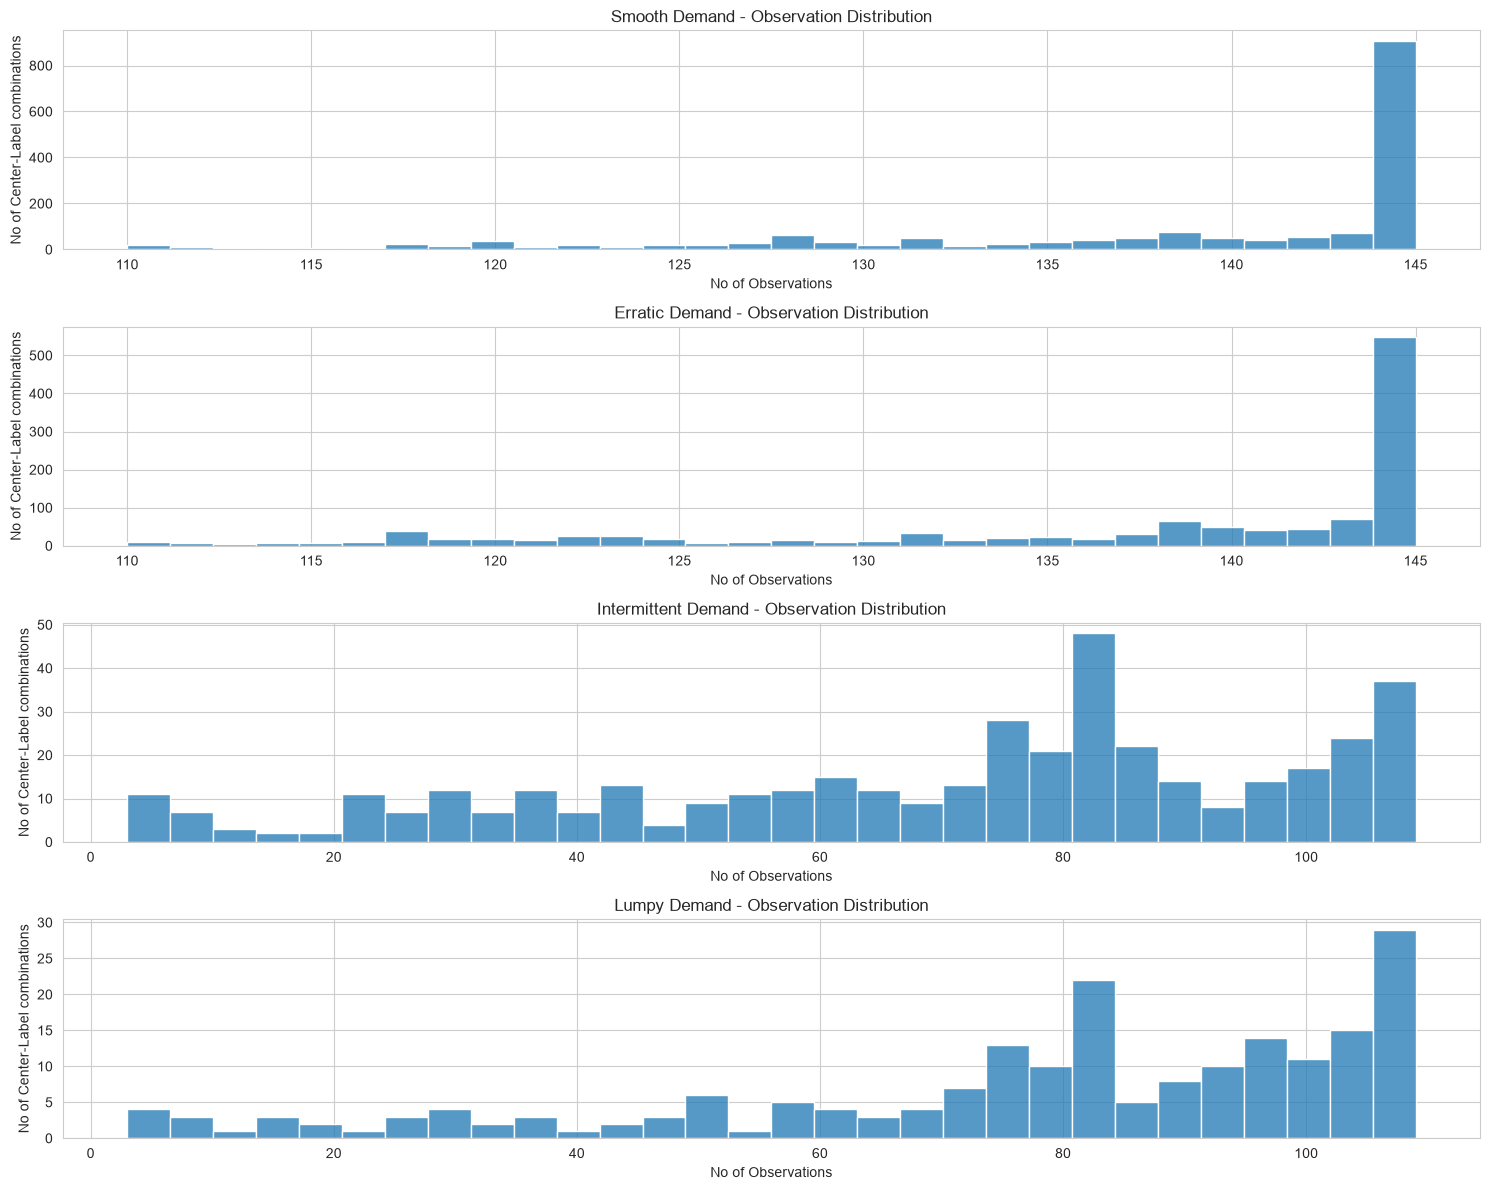

In [159]:
fig, ax = plt.subplots(nrows=4, figsize=(15, 12))
for i, sbc in enumerate(['Smooth', 'Erratic', 'Intermittent', 'Lumpy']):
    data = df_forecastibility[df_forecastibility['SBC'] == sbc]
    sns.histplot(data=data, x='non_zero_obs', bins=30,  label="Non-zero Observations", ax=ax[i])
    ax[i].set_title(f"{sbc} Demand - Observation Distribution")
    ax[i].set_xlabel("No of Observations")
    ax[i].set_ylabel("No of Center-Label combinations")
    # ax[i].grid(axis='y', aplpha=0.2)
plt.tight_layout()
plt.show()

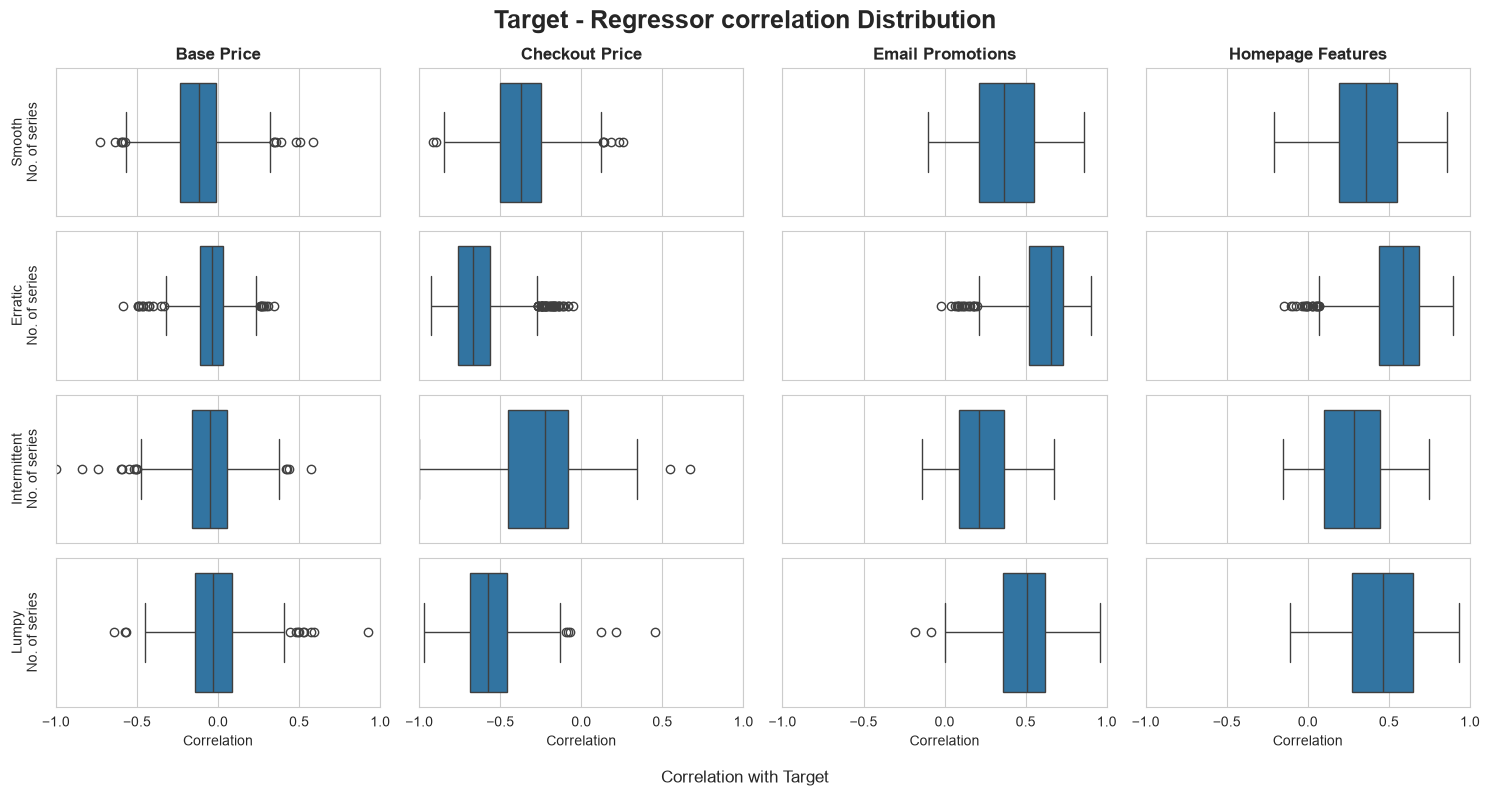

In [160]:
fig, ax = plt.subplots(nrows=4, ncols=4, figsize=(15, 8), sharex=True)

features = {
    'cor_baseprice': 'Base Price',
    'cor_checkoutprice': 'Checkout Price',
    'cor_email': 'Email Promotions',
    'cor_homepage': 'Homepage Features'
}
sbc_cat = ['Smooth', 'Erratic', 'Intermittent', 'Lumpy']

for i, sbc in enumerate(sbc_cat):
    data = df_forecastibility[df_forecastibility['SBC'] == sbc]

    for j, (feature, label) in enumerate(features.items()):
        sns.boxplot(data=data, x=feature, ax=ax[i][j])
        ax[i][j].set_xlim(-1,1)
        if i == 0:
            ax[i][j].set_title(label, fontsize=12, fontweight='bold')
        if j==0:
            ax[i][j].set_ylabel(f"{sbc}\nNo. of series")
        else:
            ax[i][j].set_ylabel("")
        if i == len(sbc_cat) - 1:
            ax[i, j].set_xlabel('Correlation')
        else:
            ax[i, j].set_xlabel('')
fig.suptitle("Target - Regressor correlation Distribution", fontsize=18, fontweight='bold')
fig.supxlabel('Correlation with Target', fontsize=12)
fig.tight_layout()
plt.show()

In [161]:
df_forecastibility.to_csv("./mywork/forecastibility.csv", index=False)

In [162]:
def get_plot(data):
    cntr = data['center_id'].iat[0]
    ml = data['meal_id'].iat[0]
    sbc = data['SBC'].iat[0]

    sns.set_style("whitegrid")
    fig, ax_left = plt.subplots(figsize=(14, 6))
    ax_right = ax_left.twinx()

    sns.lineplot(data=data, x='week', y='num_orders', ax=ax_left, label="No. of Orders", linewidth=2.5, marker='o')
    
    regressors = [
        ('base_price', 'Base Price', 'tab:orange', '-', None),
        ('checkout_price', 'Checkout Price', 'tab:green', '-', None),
        ('emailer_for_promotion', 'Email Promotion', 'tab:red', '--', None),
        ('homepage_featured', 'Homepage Featured', 'tab:purple', '--', None)
    ]
    for col, label, color, style, marker in regressors:
        sns.lineplot(data=data, x='week', y=col, ax=ax_right, label=label, color=color, linestyle=style, linewidth=2, marker=marker)

    ax_left.set_ylabel("Number of Orders", color='tab:blue')
    ax_left.tick_params(axis='y', labelcolor='tab:blue')
    ax_left.set_xlabel('Weeks')
    ax_left.set_title(f"SBC: {sbc} | Center: {cntr} | Meal: {ml}")
    ax_right.set_ylabel("Price / Promotion Variables", fontsize=11)

    plt.show()

In [163]:
df = df.merge(df_forecastibility[['center_meal', 'SBC']], on='center_meal', how='left')
df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,center_meal,SBC
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,55_1885,Smooth
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,55_1993,Smooth
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,55_2539,Smooth
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,55_2139,Intermittent
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,55_2631,Smooth


In [164]:
cntr_meal = df_forecastibility[df_forecastibility['non_zero_obs']==145]['center_meal'].unique()
len(cntr_meal)

1247

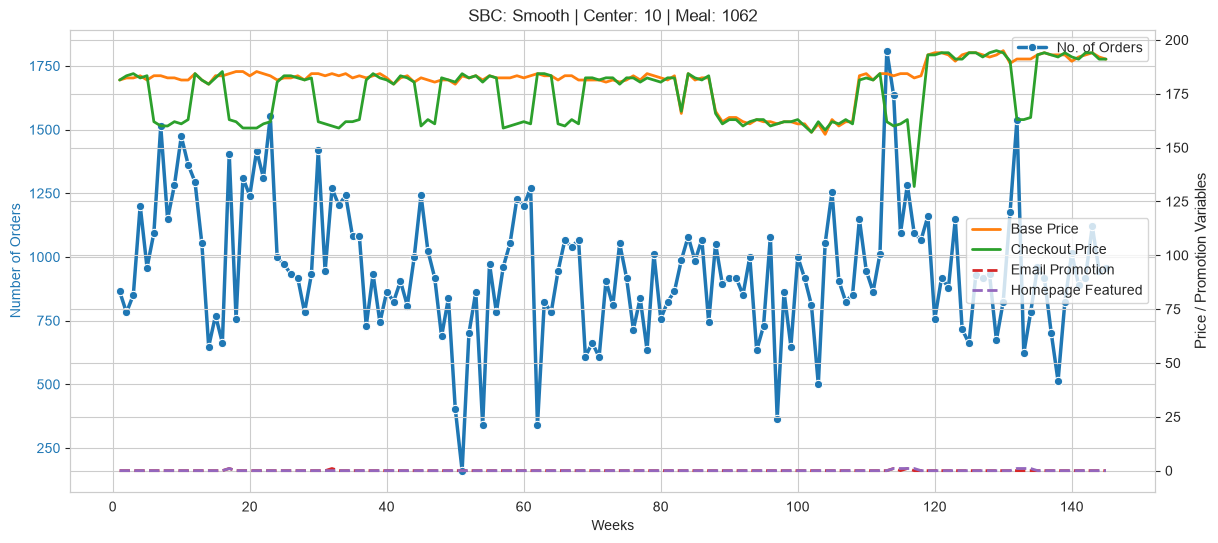

In [165]:
df_temp = df[df['center_meal']==cntr_meal[0]]
get_plot(df_temp)



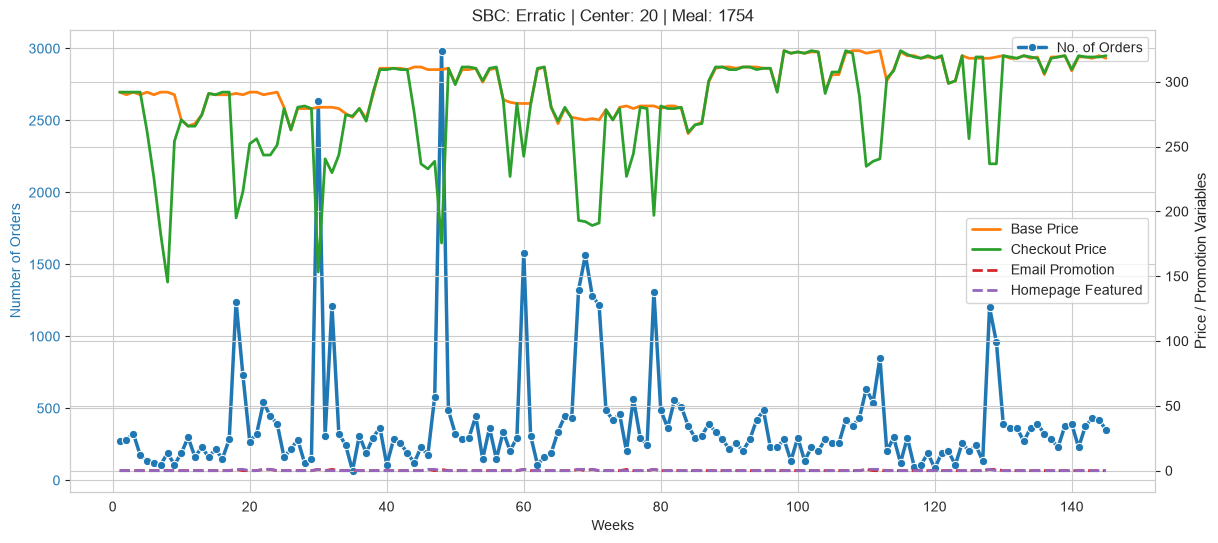

In [166]:
df_temp = df[df['center_meal']==cntr_meal[111]]
get_plot(df_temp)


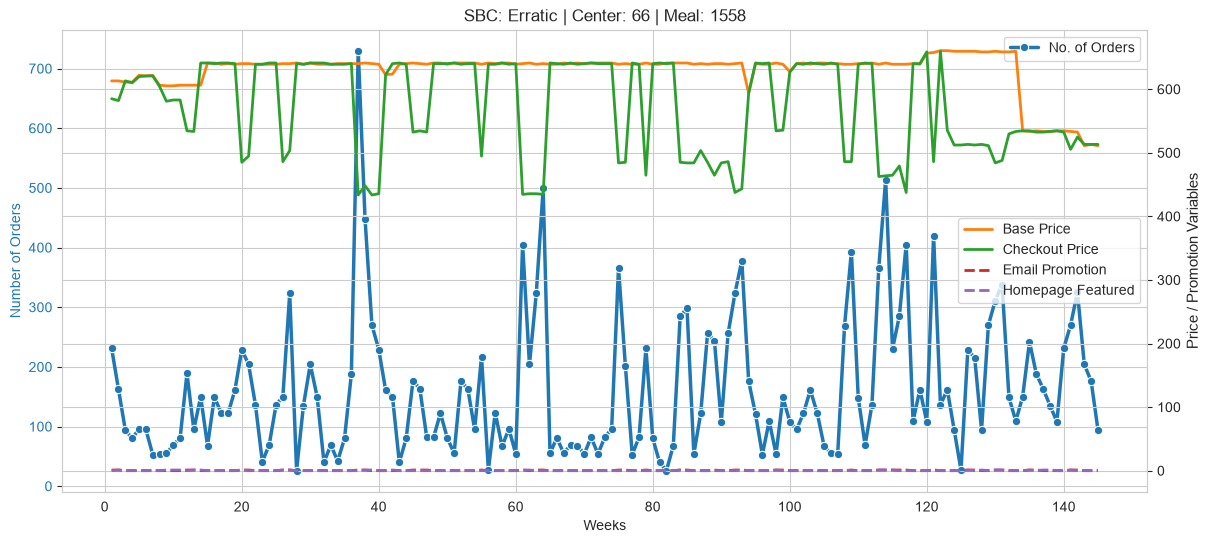

In [167]:
df_temp = df[df['center_meal']==cntr_meal[500]]
get_plot(df_temp)


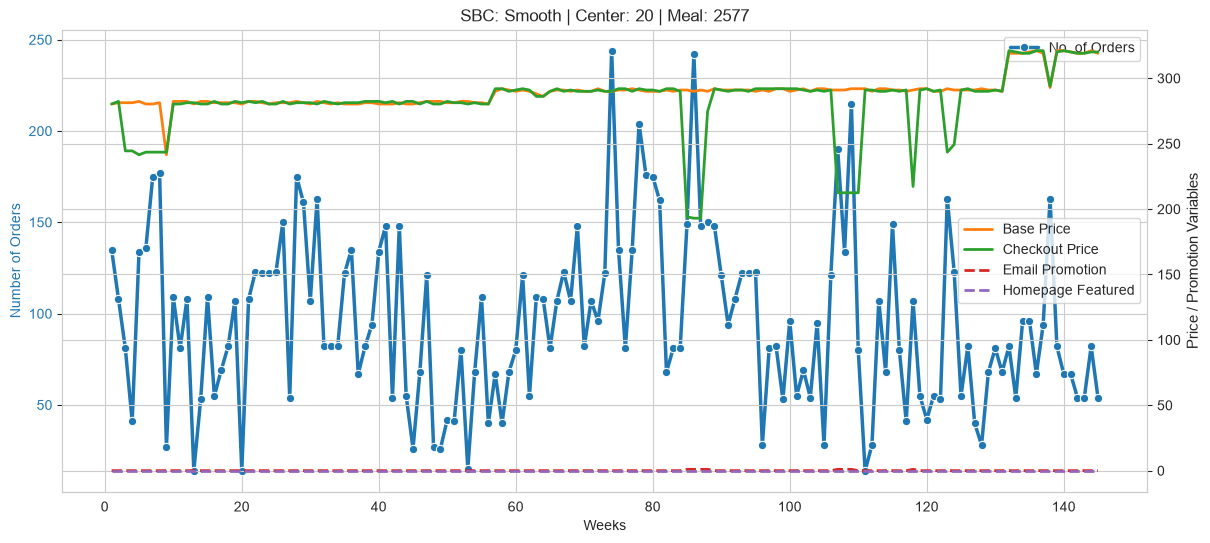

In [168]:
df_temp = df[df['center_meal']==cntr_meal[120]]
get_plot(df_temp)


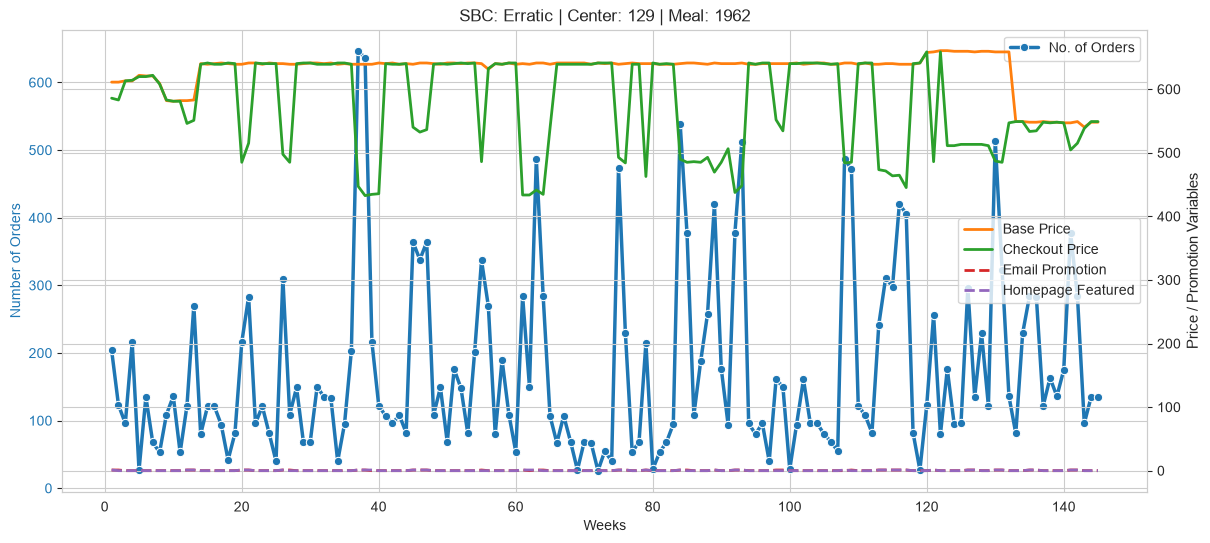

In [169]:
df_temp = df[df['center_meal']==cntr_meal[1000]]
get_plot(df_temp)


In [170]:
df_train['week'].min(), df_train['week'].max(), df_test['week'].min(), df_test['week'].max()

(np.int64(1), np.int64(145), np.int64(146), np.int64(155))

#### Prepare the data for Forecasting
* Lets assume that the data is till December and we are using Monday to calculate date
* this is done so that we can use Prophet model
* Week 155 in dec means week 1 should fall in first monday of 2023 which is 2nd Jan 2023

In [171]:
first_monday = pd.Timestamp('2023-01-02')

# Create week -> date mapping
week_date_map = {week: first_monday + pd.Timedelta(weeks = week-1) for week in range(1, df_test['week'].max()+1)}
df['date'] = df['week'].map(week_date_map)
df.head()


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,center_meal,SBC,date
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,55_1885,Smooth,2023-01-02
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,55_1993,Smooth,2023-01-02
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,55_2539,Smooth,2023-01-02
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,55_2139,Intermittent,2023-01-02
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,55_2631,Smooth,2023-01-02


In [172]:
def preprocess_data(data, center_meal):
    df_tr = data[data['center_meal']==center_meal]
    df_tr1 = df_tr[['date', 'num_orders']].rename(columns={'date': 'ds', 'num_orders': 'y'})
    scaler = StandardScaler()
    df_tr1[['checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured']] = scaler.fit_transform(
        df_tr[['checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured']]
    )
    return df_tr1, scaler

In [173]:
df_temp, _ = preprocess_data(df, cntr_meal[0])
df_temp.head()

,ds,y,checkout_price,base_price,emailer_for_promotion,homepage_featured
2370,2023-01-02,865,0.506959,0.000832,-0.16843,-0.241649
5273,2023-01-09,782,0.659387,0.106318,-0.16843,-0.241649
8175,2023-01-16,851,0.736761,0.106318,-0.16843,-0.241649
11064,2023-01-23,1202,0.582012,0.215065,-0.16843,-0.241649
13918,2023-01-30,958,0.661708,0.000832,-0.16843,-0.241649


In [174]:
param_grid = {  
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
    'seasonality_mode': ['additive', 'multiplicative']
}

# Generate all combinations of parameters
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
rmses = []

# Use cross validation to evaluate all parameters
for params in all_params:
    m = Prophet(**params).fit(df_temp)  # Fit model with given params
    df_cv = cross_validation(m, initial='742 days', period='28 days', horizon='56 days', parallel="processes")
    df_p = performance_metrics(df_cv, rolling_window=1)
    rmses.append(df_p['rmse'].values[0])

tuning_results = pd.DataFrame(all_params)
tuning_results['rmse'] = rmses
best_params = all_params[np.argmin(rmses)]
best_params

23:50:14 - cmdstanpy - INFO - Chain [1] start processing
23:50:14 - cmdstanpy - INFO - Chain [1] done processing
23:50:18 - cmdstanpy - INFO - Chain [1] start processing
23:50:18 - cmdstanpy - INFO - Chain [1] done processing
23:50:22 - cmdstanpy - INFO - Chain [1] start processing
23:50:22 - cmdstanpy - INFO - Chain [1] done processing
23:50:26 - cmdstanpy - INFO - Chain [1] start processing
23:50:26 - cmdstanpy - INFO - Chain [1] done processing
23:50:32 - cmdstanpy - INFO - Chain [1] start processing
23:50:32 - cmdstanpy - INFO - Chain [1] done processing
23:50:38 - cmdstanpy - INFO - Chain [1] start processing
23:50:38 - cmdstanpy - INFO - Chain [1] done processing
23:50:43 - cmdstanpy - INFO - Chain [1] start processing
23:50:43 - cmdstanpy - INFO - Chain [1] done processing
23:50:49 - cmdstanpy - INFO - Chain [1] start processing
23:50:49 - cmdstanpy - INFO - Chain [1] done processing
23:50:54 - cmdstanpy - INFO - Chain [1] start processing
23:50:54 - cmdstanpy - INFO - Chain [1]

{'changepoint_prior_scale': 0.01,
 'seasonality_prior_scale': 0.1,
 'seasonality_mode': 'multiplicative'}

In [175]:
m = Prophet(**best_params)
m.add_regressor('checkout_price')
m.add_regressor('emailer_for_promotion')
m.add_regressor('homepage_featured')
m.fit(df_temp)

forecast = m.predict(df_temp)
forecast = forecast.merge(df_temp[['ds', 'y']], on='ds', how='outer')
forecast.tail()

23:52:44 - cmdstanpy - INFO - Chain [1] start processing
23:52:44 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,checkout_price,checkout_price_lower,checkout_price_upper,emailer_for_promotion,...,multiplicative_terms_lower,multiplicative_terms_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat,y
140,2025-09-08,921.317367,554.533648,1059.679886,921.317367,921.317367,-0.137629,-0.137629,-0.137629,-0.009589,...,-0.125289,-0.125289,0.018945,0.018945,0.018945,0.0,0.0,0.0,805.886123,890
141,2025-09-15,921.129079,531.682877,1047.940875,921.129079,921.129079,-0.162526,-0.162526,-0.162526,-0.009589,...,-0.140442,-0.140442,0.028689,0.028689,0.028689,0.0,0.0,0.0,791.763474,919
142,2025-09-22,920.940791,499.756548,1031.920856,920.940791,920.940791,-0.162526,-0.162526,-0.162526,-0.009589,...,-0.160333,-0.160333,0.008799,0.008799,0.008799,0.0,0.0,0.0,773.283847,1120
143,2025-09-29,920.752503,498.399870,1023.444369,920.752503,920.752503,-0.137629,-0.137629,-0.137629,-0.009589,...,-0.173324,-0.173324,-0.029090,-0.029090,-0.029090,0.0,0.0,0.0,761.163621,945
144,2025-10-06,920.564215,474.555606,983.821153,920.564215,920.564215,-0.137629,-0.137629,-0.137629,-0.009589,...,-0.202773,-0.202773,-0.058539,-0.058539,-0.058539,0.0,0.0,0.0,733.898195,958


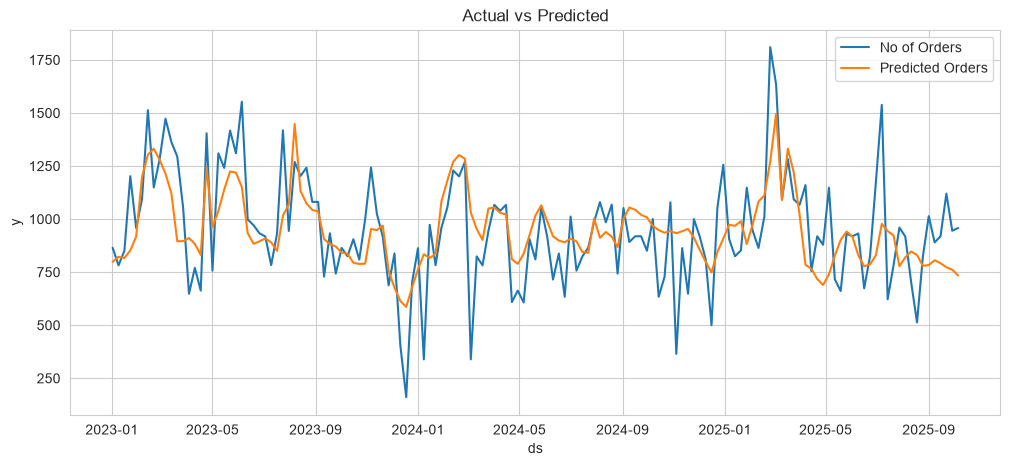

In [176]:
plt.figure(figsize=(12,5))
sns.lineplot(data=forecast, x='ds', y='y', label='No of Orders')
sns.lineplot(data=forecast, x='ds', y='yhat', label='Predicted Orders')
plt.title("Actual vs Predicted")
plt.show()